In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/home/devjith/Luminar/Machine Learning/files/Titanic-Dataset.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3.0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3.0,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3.0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2.0,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1.0,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1.0,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           5
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

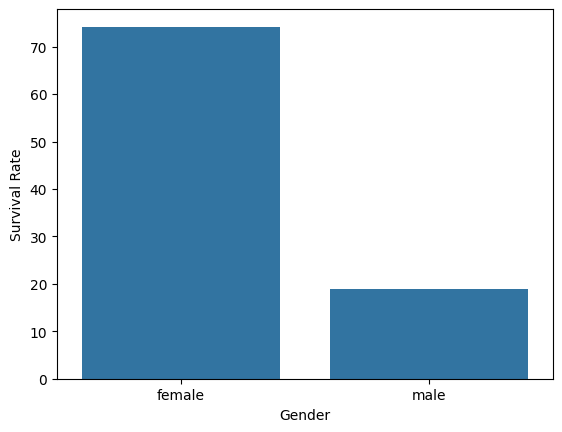

Male survival rate: 18.89%
Female survival rate: 74.20%


In [6]:

survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100


sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values)
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()


print(f"Male survival rate: {survival_by_sex['male']:.2f}%")
print(f"Female survival rate: {survival_by_sex['female']:.2f}%")

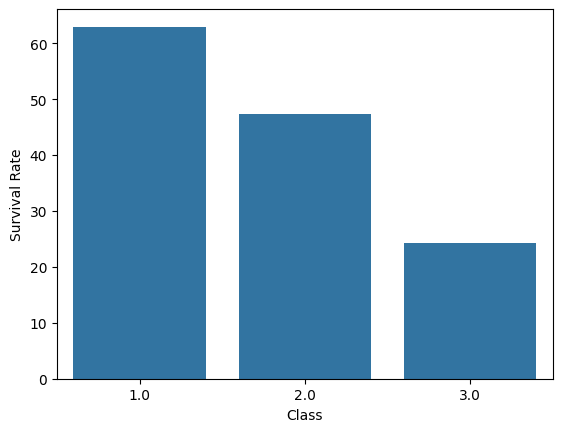

In [7]:
df['Pclass'] = df['Pclass'].fillna(df['Pclass'].mode()[0])

survival_by_class = df.groupby('Pclass')['Survived'].mean() *100


sns.barplot(x=survival_by_class.index,y = survival_by_class.values)
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()

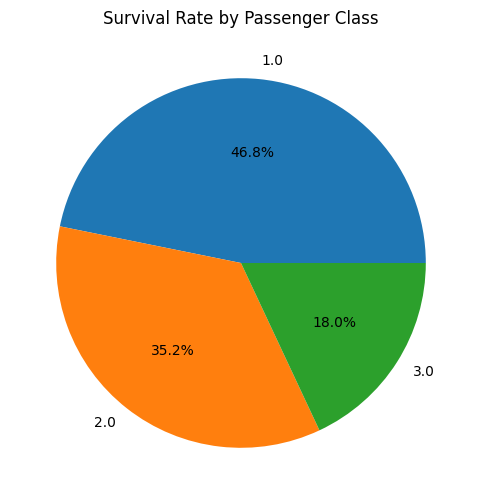

In [8]:
plt.figure(figsize=(6, 6))
plt.pie(survival_by_class.values, labels=survival_by_class.index.astype(str), autopct='%1.1f%%')
plt.title('Survival Rate by Passenger Class')
plt.show()

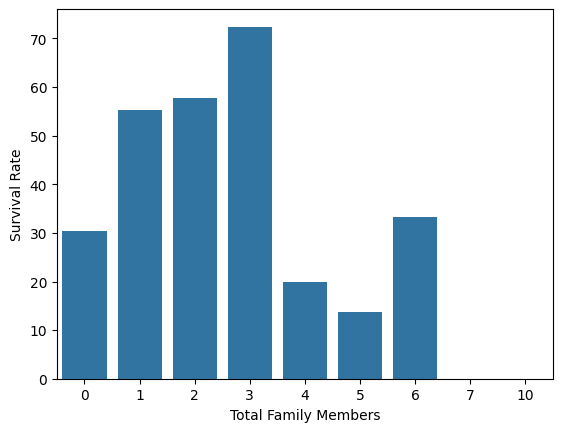

In [9]:
df['total_family_members'] = df['SibSp']+df['Parch']
survival_by_family_members = df.groupby('total_family_members')['Survived'].mean()*100

sns.barplot(x = survival_by_family_members.index,y = survival_by_family_members.values)
plt.xlabel("Total Family Members")
plt.ylabel("Survival Rate")
plt.show()


([<matplotlib.patches.Wedge at 0x7a8ee686cb00>,
 [Text(0.23409050730436445, 1.074803067724495, 'C'),
  Text(-0.951462041242301, -0.5520144781389652, 'Q'),
  Text(0.741849762308576, -0.8121938993631442, 'S')],
 [Text(0.12768573125692606, 0.5862562187588154, '43.2%'),
  Text(-0.5189792952230732, -0.3010988062576173, '30.4%'),
  Text(0.40464532489558686, -0.4430148541980787, '26.4%')])

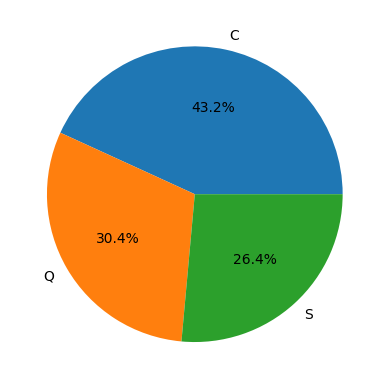

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

survival_by_embark = df.groupby('Embarked')['Survived'].mean()*100

plt.pie(survival_by_embark.values,labels=survival_by_embark.index,autopct='%1.1f%%')

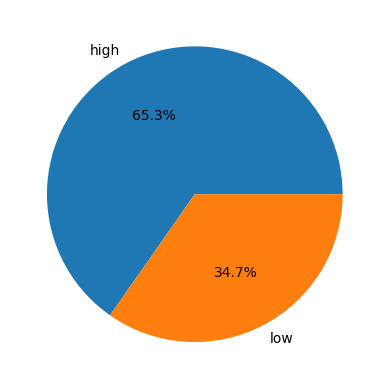

In [11]:
mean_fare = df['Fare'].mean()

df['fare_type'] = df['Fare'].apply(lambda x: 'high' if x > mean_fare else 'low')


survival_by_fare_type = df.groupby('fare_type')['Survived'].mean() * 100

plt.pie(survival_by_fare_type.values,labels=survival_by_fare_type.index,autopct = '%1.1f%%')

plt.show()

In [12]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,total_family_members,fare_type
0,1,0,3.0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,low
1,2,1,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,high
2,3,1,3.0,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,low
3,4,1,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,high
4,5,0,3.0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2.0,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,low
887,888,1,1.0,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,low
888,889,0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3,low
889,890,1,1.0,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,low


In [13]:
df = df.drop(columns='PassengerId')

In [14]:
df = df.drop(columns=['Name','Ticket'])

In [15]:
df = df.drop(columns='fare_type')

In [16]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,total_family_members
0,0,3.0,male,22.0,1,0,7.2500,NaN,S,1
1,1,1.0,female,38.0,1,0,71.2833,C85,C,1
2,1,3.0,female,26.0,0,0,7.9250,NaN,S,0
3,1,1.0,female,35.0,1,0,53.1000,C123,S,1
4,0,3.0,male,35.0,0,0,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2.0,male,27.0,0,0,13.0000,NaN,S,0
887,1,1.0,female,19.0,0,0,30.0000,B42,S,0
888,0,3.0,female,NaN,1,2,23.4500,NaN,S,3
889,1,1.0,male,26.0,0,0,30.0000,C148,C,0


In [17]:
df = df.drop(columns='Cabin')

In [18]:
df_enc = pd.get_dummies(df[['Sex','Embarked']],drop_first=True,dtype=int)
df = pd.concat([df,df_enc],axis=1)
df = df.drop(columns=['Sex','Embarked'])

In [19]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,total_family_members,Sex_male,Embarked_Q,Embarked_S
0,0,3.0,22.0,1,0,7.2500,1,1,0,1
1,1,1.0,38.0,1,0,71.2833,1,0,0,0
2,1,3.0,26.0,0,0,7.9250,0,0,0,1
3,1,1.0,35.0,1,0,53.1000,1,0,0,1
4,0,3.0,35.0,0,0,8.0500,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2.0,27.0,0,0,13.0000,0,1,0,1
887,1,1.0,19.0,0,0,30.0000,0,0,0,1
888,0,3.0,NaN,1,2,23.4500,3,0,0,1
889,1,1.0,26.0,0,0,30.0000,0,1,0,0


In [20]:
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])

In [21]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,total_family_members,Sex_male,Embarked_Q,Embarked_S
0,0,3.0,22.0,1,0,7.2500,1,1,0,1
1,1,1.0,38.0,1,0,71.2833,1,0,0,0
2,1,3.0,26.0,0,0,7.9250,0,0,0,1
3,1,1.0,35.0,1,0,53.1000,1,0,0,1
4,0,3.0,35.0,0,0,8.0500,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2.0,27.0,0,0,13.0000,0,1,0,1
887,1,1.0,19.0,0,0,30.0000,0,0,0,1
888,0,3.0,24.0,1,2,23.4500,3,0,0,1
889,1,1.0,26.0,0,0,30.0000,0,1,0,0


In [22]:
x = df.drop(columns=['Survived','total_family_members'])
y = df['Survived']

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [29]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       157
           1       0.76      0.71      0.73       111

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268

